## Social Media Content Engagement Prediction

**Problem Statement**

Brands, influencers, and digital marketing teams constantly try to understand which type of content is likely to generate stronger audience response. Engagement typically includes likes, comments, shares, saves, clicks, and other meaningful interactions that indicate how users respond to a post. Predicting engagement in advance helps marketers improve content planning, posting strategy, audience targeting, and campaign effectiveness. In this project, the objective is to predict the engagement_score of a social media post using post-level, timing-level, audience-level, and campaign-level variables. Since the target is a continuous numeric value, this problem is treated as a regression task.

**Data Dictionary**

**Column**          **Description**

post_type:          Type of post such as image, carousel, reel, or video

caption_length :     Total number of characters in the caption

hashtags_count  :    Number of hashtags used in the post

mentions_count   :   Number of tagged accounts or mentions

emoji_count       :  Number of emojis used in the caption

has_call_to_action:  Whether the caption contains a call-to-action

uses_trending_audio: Whether the post uses trending audio

content_topic    :   Main topic category of the content

hour_posted       :  Hour at which the content was posted

day_of_week        : Day of the week when the post was published

is_weekend          :Indicates whether the post was published on a weekend

followers_count     :Total followers of the account

audience_active_percent: Estimated percentage of followers active at posting time

avg_past_engagement :Average engagement score of past posts

account_age_days   : Age of the account in days

impressions         :Total number of times the post was shown

reach               :Number of unique users reached

profile_visits     : Number of profile visits generated by the post

watch_time_seconds  :Total watch time in seconds for video-based content

completion_rate    : Percentage of viewers who watched the content fully

click_through_rate : Percentage of users who clicked the link or CTA

is_paid_promotion  : Whether the post received paid promotion support

ad_spend        :    Amount spent on promoting the content

collaboration_flag : Whether the post is a collaboration post

engagement_score  :  Target variable representing overall post engagement

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("social_media_engagement.csv");

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   platform                    10000 non-null  object 
 1   content_type                10000 non-null  object 
 2   content_topic               10000 non-null  object 
 3   creator_category            10000 non-null  object 
 4   post_hour                   10000 non-null  int64  
 5   day_of_week                 10000 non-null  int64  
 6   is_weekend                  10000 non-null  int64  
 7   is_peak_time                10000 non-null  int64  
 8   caption_length              10000 non-null  int64  
 9   hashtag_count               10000 non-null  int64  
 10  mention_count               10000 non-null  int64  
 11  emoji_count                 10000 non-null  int64  
 12  has_call_to_action          10000 non-null  int64  
 13  uses_trending_audio         1000

In [10]:
df.describe()

,post_hour,day_of_week,is_weekend,is_peak_time,caption_length,hashtag_count,mention_count,emoji_count,has_call_to_action,uses_trending_audio,...,sentiment_score_caption,followers_count,audience_active_percent,avg_past_engagement,posting_frequency_per_week,account_age_days,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.573100,2.983200,0.282900,0.339800,140.808500,7.029200,1.217700,3.023400,0.457300,0.162500,...,0.140095,3.712523e+04,48.212065,867.760119,4.850620,852.542900,0.240800,69.462306,0.168100,996.671475
std,6.896406,2.001379,0.450431,0.473665,67.123003,2.712173,1.102011,1.752529,0.498198,0.368927,...,0.438538,5.067756e+04,13.907942,492.615875,2.015644,414.907001,0.427591,221.278331,0.373974,107.029183
min,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,7.350000e+02,8.000000,30.000000,1.000000,30.000000,0.000000,0.000000,0.000000,525.470000
25%,6.000000,1.000000,0.000000,0.000000,93.000000,5.000000,0.000000,2.000000,0.000000,0.000000,...,-0.165000,1.079450e+04,38.650000,509.225000,3.400000,562.000000,0.000000,0.000000,0.000000,923.180000
50%,12.000000,3.000000,0.000000,0.000000,140.000000,7.000000,1.000000,3.000000,0.000000,0.000000,...,0.144000,2.221400e+04,48.370000,851.490000,4.800000,850.000000,0.000000,0.000000,0.000000,994.055000
75%,18.000000,5.000000,1.000000,1.000000,186.000000,9.000000,2.000000,4.000000,1.000000,0.000000,...,0.448000,4.420475e+04,57.600000,1205.830000,6.200000,1136.000000,0.000000,0.000000,0.000000,1066.642500
max,23.000000,6.000000,1.000000,1.000000,429.000000,21.000000,8.000000,12.000000,1.000000,1.000000,...,1.000000,1.728174e+06,96.000000,2810.410000,12.300000,2556.000000,1.000000,5193.630000,1.000000,1447.810000


In [11]:
df.columns

Index(['platform', 'content_type', 'content_topic', 'creator_category',
       'post_hour', 'day_of_week', 'is_weekend', 'is_peak_time',
       'caption_length', 'hashtag_count', 'mention_count', 'emoji_count',
       'has_call_to_action', 'uses_trending_audio', 'carousel_slides',
       'video_duration_sec', 'media_quality_score', 'sentiment_score_caption',
       'followers_count', 'audience_active_percent', 'avg_past_engagement',
       'posting_frequency_per_week', 'account_age_days', 'is_paid_promotion',
       'ad_spend_usd', 'collaboration_flag', 'engagement_score'],
      dtype='object')

In [12]:
df.isnull().sum()

platform                      0
content_type                  0
content_topic                 0
creator_category              0
post_hour                     0
day_of_week                   0
is_weekend                    0
is_peak_time                  0
caption_length                0
hashtag_count                 0
mention_count                 0
emoji_count                   0
has_call_to_action            0
uses_trending_audio           0
carousel_slides               0
video_duration_sec            0
media_quality_score           0
sentiment_score_caption       0
followers_count               0
audience_active_percent       0
avg_past_engagement           0
posting_frequency_per_week    0
account_age_days              0
is_paid_promotion             0
ad_spend_usd                  0
collaboration_flag            0
engagement_score              0
dtype: int64

**EDA Questions**

**A. Understanding the Target Variable**

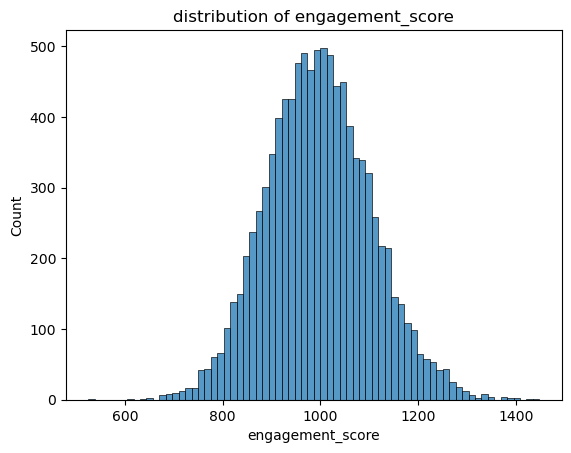

In [13]:
#1. What is the distribution of engagement_score?
sns.histplot(df['engagement_score'])
plt.title('distribution of engagement_score')
plt.show()

In [22]:
#2. Is the engagement_score normally distributed, skewed, or multimodal?
print(df['engagement_score'].skew())

0.15472122166940916


This is positively skewed means it is high-engagement posts are less frequent but extreme.

In [23]:
#3. What are the minimum, maximum, mean, and median values of engagement_score?
print("Min:",df['engagement_score'].min())
print("Max:",df['engagement_score'].max())
print("Mean:",df['engagement_score'].mean())
print("Median:",df['engagement_score'].median())

Min: 525.47
Max: 1447.81
Mean: 996.671475
Median: 994.0550000000001


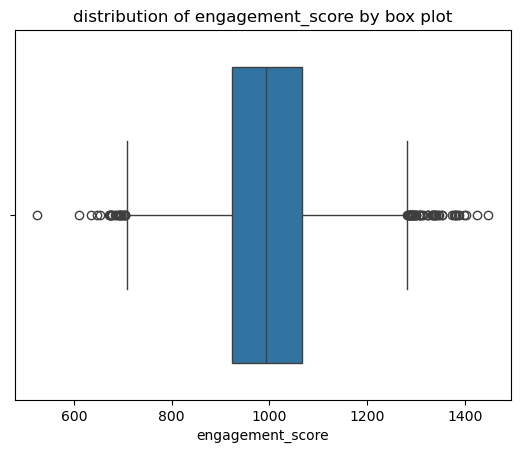

In [24]:
#4. Are there extreme outliers in engagement_score?
sns.boxplot(x=df['engagement_score'])
plt.title('distribution of engagement_score by box plot')
plt.show()

there are extreme outliers visible in the upper range, representing viral or highly successful posts.

In [25]:
#5. What percentage of posts have very low engagement compared to the rest?
low_threshold=df['engagement_score'].quantile(0.25)
low_percent=(df['engagement_score']<low_threshold).mean()*100
print(low_percent)

24.990000000000002


In [26]:
#6. What percentage of posts achieve exceptionally high engagement?
high_threshold = df['engagement_score'].quantile(0.90)
high_percent = (df['engagement_score']>high_threshold).mean()*100
print(high_percent)

10.0


In [27]:
#7. Does engagement_score vary widely across the dataset or remain concentrated in a narrow band?
df['engagement_score'].describe()

count    10000.000000
mean       996.671475
std        107.029183
min        525.470000
25%        923.180000
50%        994.055000
75%       1066.642500
max       1447.810000
Name: engagement_score, dtype: float64

In [30]:
#8. Should the target variable be transformed because of skewness or extreme spread?


Due to positive skewness and presence of outliers, applying a log transformation may improve model performance by stabilizing variance.

In [32]:
#9. How stable is engagement_score across different post categories?
df.groupby('content_type')['engagement_score'].mean()

content_type
Carousel    1000.612013
Image        971.951577
Reel        1040.843544
Text         963.256707
Video       1014.336697
Name: engagement_score, dtype: float64

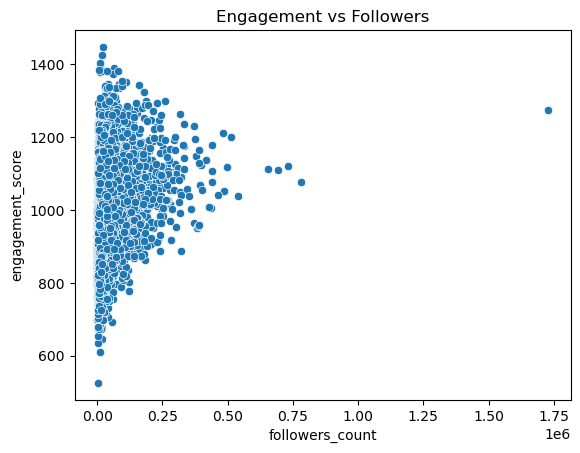

In [34]:
#10. Are there unusual patterns in engagement_score that may need further investigation?
sns.scatterplot(x='followers_count', y='engagement_score', data=df)
plt.title("Engagement vs Followers")
plt.show()

In [35]:
df.groupby('is_paid_promotion')['engagement_score'].mean()

is_paid_promotion
0    996.328327
1    997.753360
Name: engagement_score, dtype: float64

In [36]:
df.groupby('collaboration_flag')['engagement_score'].mean()

collaboration_flag
0     992.437515
1    1017.624664
Name: engagement_score, dtype: float64

In [37]:
df.groupby('uses_trending_audio')['engagement_score'].mean()

uses_trending_audio
0     985.671669
1    1053.362782
Name: engagement_score, dtype: float64

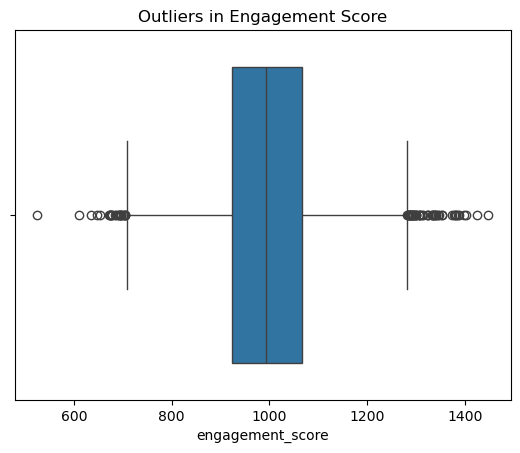

In [38]:
sns.boxplot(x=df['engagement_score'])
plt.title("Outliers in Engagement Score")
plt.show()

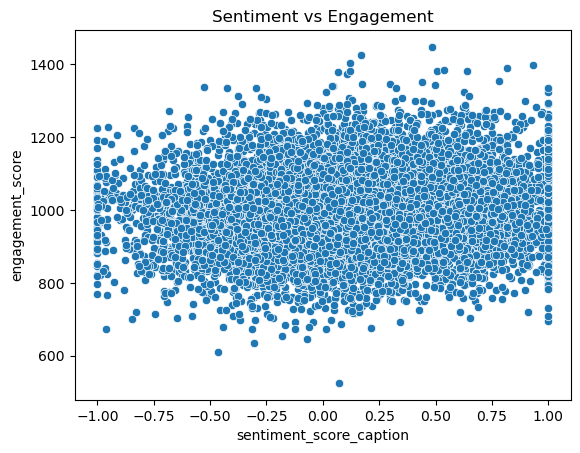

In [39]:
sns.scatterplot(x='sentiment_score_caption', y='engagement_score', data=df)
plt.title("Sentiment vs Engagement")
plt.show()

-High followers but low engagement which indicates poor content quality or inactive audience

-Low followers but very high engagement which means possible viral content or strong niche audience

-Paid posts with low engagement which are ineffective ad spend

-Sudden extreme outliers means viral spikes or data errors

-No clear trend between sentiment & engagement that indicates caption sentiment may not strongly influence engagement

**B. Post Content Analysis**

In [50]:
#11. Which post_type generates the highest average engagement_score?
df.groupby('content_type')['engagement_score'].mean().sort_values(ascending=False)

content_type
Reel        1040.843544
Video       1014.336697
Carousel    1000.612013
Image        971.951577
Text         963.256707
Name: engagement_score, dtype: float64

In [51]:
#12. Which content_topic performs best on average?
df.groupby('content_topic')['engagement_score'].mean().sort_values(ascending=False)

content_topic
Education            1006.281195
Entertainment         998.740662
Lifestyle             997.941754
Behind-the-scenes     994.174983
News                  993.977270
Product               990.923692
Motivation            989.621157
Name: engagement_score, dtype: float64

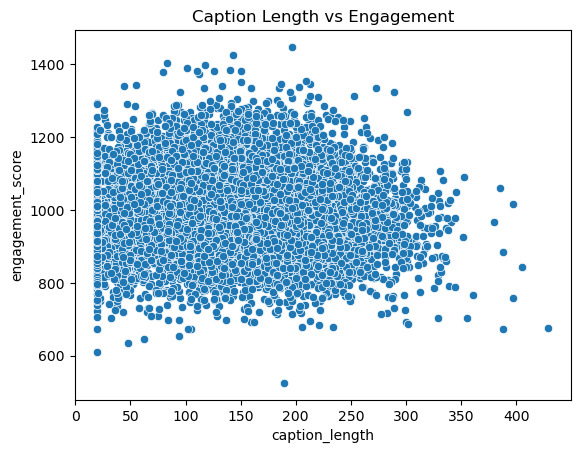

In [52]:
#13. Does caption_length show any relationship with engagement_score?
sns.scatterplot(x='caption_length', y='engagement_score', data=df)
plt.title("Caption Length vs Engagement")
plt.show()

In [56]:
#14. Is there an ideal caption length range associated with stronger engagement?
df['caption_length_bin']=pd.cut(df['caption_length'], bins=5)
df.groupby('caption_length_bin',observed=True)['engagement_score'].mean()

caption_length_bin
(19.591, 101.8]     992.775971
(101.8, 183.6]     1002.770647
(183.6, 265.4]      995.821971
(265.4, 347.2]      960.284721
(347.2, 429.0]      863.984167
Name: engagement_score, dtype: float64

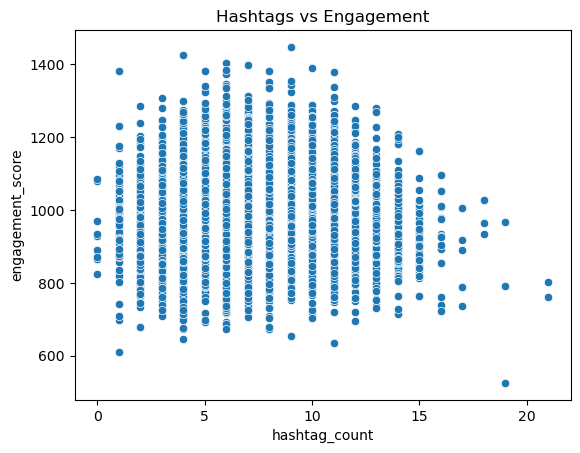

In [57]:
#15. How does hashtags_count affect engagement_score?
sns.scatterplot(x='hashtag_count', y='engagement_score', data=df)
plt.title("Hashtags vs Engagement")
plt.show()

In [61]:
#16. Do too many hashtags reduce engagement after a certain point?
df['hashtag_bin'] = pd.cut(df['hashtag_count'], bins=[0,5,10,20,50])
df.groupby('hashtag_bin', observed=False)['engagement_score'].mean()

hashtag_bin
(0, 5]       989.380856
(5, 10]     1004.117582
(10, 20]     976.261330
(20, 50]     781.350000
Name: engagement_score, dtype: float64

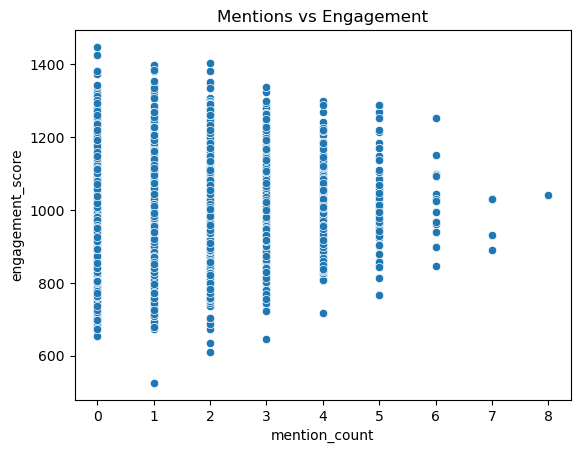

In [62]:
#17. Does mentions_count contribute positively to engagement_score?
sns.scatterplot(x='mention_count', y='engagement_score', data=df)
plt.title("Mentions vs Engagement")
plt.show()

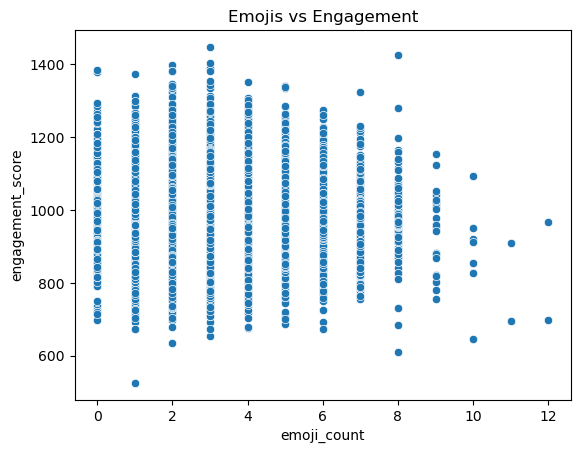

In [63]:
#18. How does emoji_count influence engagement_score?
sns.scatterplot(x='emoji_count', y='engagement_score', data=df)
plt.title("Emojis vs Engagement")
plt.show()

In [64]:
#19. Do posts with has_call_to_action = 1 perform better than those without it?
df.groupby('has_call_to_action')['engagement_score'].mean()

has_call_to_action
0     990.331844
1    1004.195021
Name: engagement_score, dtype: float64

In [65]:
#20. Does uses_trending_audio improve engagement_score for relevant post types?
df.groupby('uses_trending_audio')['engagement_score'].mean()

uses_trending_audio
0     985.671669
1    1053.362782
Name: engagement_score, dtype: float64

**C. Time-Based Analysis**

In [76]:
#21. Which hour_posted is associated with the highest average engagement_score?
df.groupby('post_hour')['engagement_score'].mean().sort_values(ascending=False)

post_hour
13    1009.371069
21    1006.887814
19    1005.116831
18    1004.880594
20    1004.254624
12    1003.242896
22    1002.423804
7     1001.029400
11     998.882346
17     998.203963
3      997.597241
10     996.883311
5      995.865429
14     992.468939
8      992.260544
6      992.099286
4      991.852470
0      990.241735
23     990.001734
2      989.737881
1      989.512727
9      989.472884
15     988.202588
16     987.599143
Name: engagement_score, dtype: float64

In [77]:
#22. Which day_of_week gives the best engagement performance?
df.groupby('day_of_week')['engagement_score'].mean().sort_values(ascending=False)

day_of_week
2    1001.405243
0     999.168181
3     998.994648
4     995.986988
6     995.555566
5     994.914798
1     990.610192
Name: engagement_score, dtype: float64

In [78]:
#23. Do weekend posts perform differently from weekday posts?
df.groupby('is_weekend')['engagement_score'].mean()

is_weekend
0    997.235733
1    995.241184
Name: engagement_score, dtype: float64

In [79]:
#24. Is there a clear peak posting window where engagement_score increases significantly?
df.groupby('post_hour')['engagement_score'].mean()

post_hour
0      990.241735
1      989.512727
2      989.737881
3      997.597241
4      991.852470
5      995.865429
6      992.099286
7     1001.029400
8      992.260544
9      989.472884
10     996.883311
11     998.882346
12    1003.242896
13    1009.371069
14     992.468939
15     988.202588
16     987.599143
17     998.203963
18    1004.880594
19    1005.116831
20    1004.254624
21    1006.887814
22    1002.423804
23     990.001734
Name: engagement_score, dtype: float64

In [80]:
#25. Does the relationship between posting hour and engagement differ by post_type?
df.groupby(['post_hour', 'content_type'])['engagement_score'].mean().unstack()

content_type,Carousel,Image,Reel,Text,Video
post_hour,,,,,
0,990.498923,968.028878,1035.261791,952.452941,1013.800200
1,988.037115,960.451183,1025.117419,965.951702,1013.330684
2,993.645763,953.880575,1035.782297,962.413117,1007.357222
3,1015.332340,971.468353,1045.206667,962.780989,1005.617714
4,1006.265660,963.915312,1055.321667,949.237294,1000.596396
5,992.008462,976.029857,1041.694810,952.639394,1019.281146
6,1003.723188,961.281029,1043.489605,953.502143,1004.419789
7,1000.208710,968.802222,1057.914412,970.855122,1016.921633
8,1002.075968,955.418105,1025.099028,973.272921,1013.374857


In [83]:
#26. Which combination of day_of_week and hour_posted performs best?
df.groupby(['day_of_week','post_hour'])['engagement_score'].mean().sort_values(ascending=False).head(10)

day_of_week  post_hour
4            21           1042.713409
0            13           1029.590339
3            13           1028.043467
             12           1026.655000
2            21           1025.161250
5            22           1024.310185
             7            1022.143269
             20           1020.276038
0            20           1019.660658
2            18           1018.600656
Name: engagement_score, dtype: float64

In [84]:
#27. Are late-night posts weaker or stronger than daytime posts?
def time_category(hour):
    if hour < 6:
        return 'late_night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'afternoon'
    else:
        return 'evening'

df['time_category'] = df['post_hour'].apply(time_category)
df.groupby('time_category')['engagement_score'].mean()

time_category
afternoon      996.739267
evening       1002.245813
late_night     992.449721
morning        995.111702
Name: engagement_score, dtype: float64

In [87]:
#28. Does the impact of posting time vary by content_topic?
df.groupby(['post_hour','content_topic'])['engagement_score'].mean().unstack()

content_topic,Behind-the-scenes,Education,Entertainment,Lifestyle,Motivation,News,Product
post_hour,,,,,,,
0,1002.145636,1004.503377,987.328961,978.329091,980.402833,992.195366,982.978800
1,995.313137,982.792800,997.282344,1001.073654,999.646949,974.287045,978.303973
2,992.286857,995.813425,1000.495946,984.290357,945.806977,991.493962,1004.307547
3,1005.457037,1000.432667,992.640820,1001.765102,999.913276,986.288974,994.279000
4,969.864000,1009.387101,1008.530405,982.516061,986.490000,993.391163,985.116377
5,972.512143,1028.866552,997.833387,998.221167,968.427843,1023.699118,990.309867
6,983.523800,1013.291270,970.221408,993.788649,1000.986222,992.094737,993.980154
7,1010.891875,1023.870253,1014.695797,1018.044844,960.284286,969.694340,991.867778
8,957.544902,991.165581,999.609540,993.479825,1013.211087,960.141316,1016.615862


In [88]:
#29. Are some time slots consistently underperforming?
df.groupby('post_hour')['engagement_score'].mean().sort_values().head(5)

post_hour
16    987.599143
15    988.202588
9     989.472884
1     989.512727
2     989.737881
Name: engagement_score, dtype: float64

In [89]:
#30. Is posting time a strong predictor of engagement_score compared to content variables?
df[['post_hour','engagement_score']].corr()

,post_hour,engagement_score
post_hour,1.000000,0.028077
engagement_score,0.028077,1.000000


**D. Audience and Account Analysis**

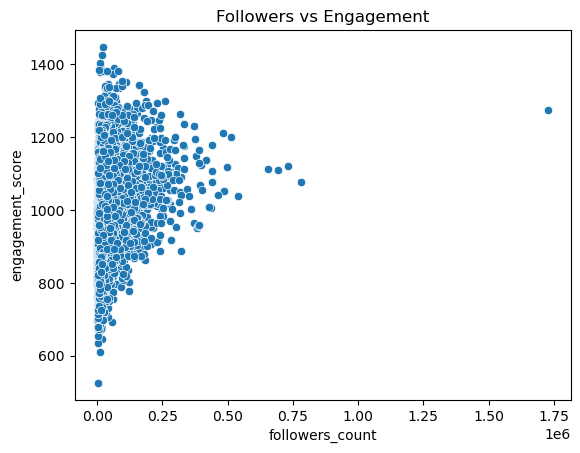

In [100]:
#31. How strongly is followers_count related to engagement_score?
sns.scatterplot(x='followers_count', y='engagement_score', data=df)
plt.title("Followers vs Engagement")
plt.show()

In [101]:
df[['followers_count','engagement_score']].corr()

,followers_count,engagement_score
followers_count,1.000000,0.251904
engagement_score,0.251904,1.000000


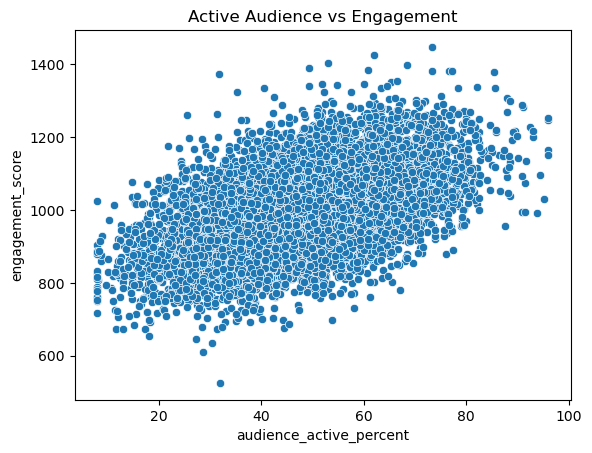

In [103]:
#32. Does audience_active_percent influence engagement_score positively?
sns.scatterplot(x='audience_active_percent', y='engagement_score', data=df)
plt.title("Active Audience vs Engagement")
plt.show()

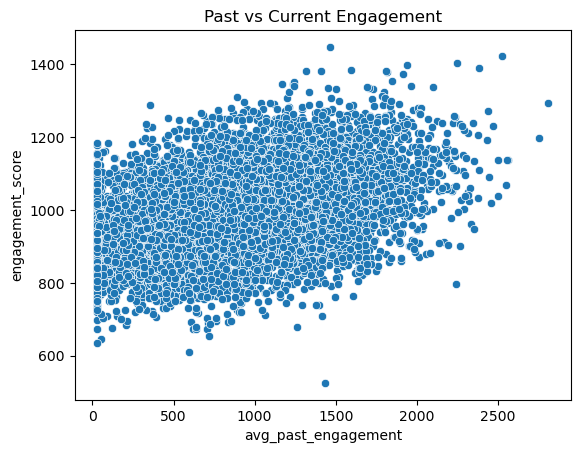

In [105]:
#33. Is avg_past_engagemesns.scatterplot(x='avg_past_engagement', y='engagement_score', data=df)
sns.scatterplot(x='avg_past_engagement', y='engagement_score', data=df)
plt.title("Past vs Current Engagement")
plt.show()

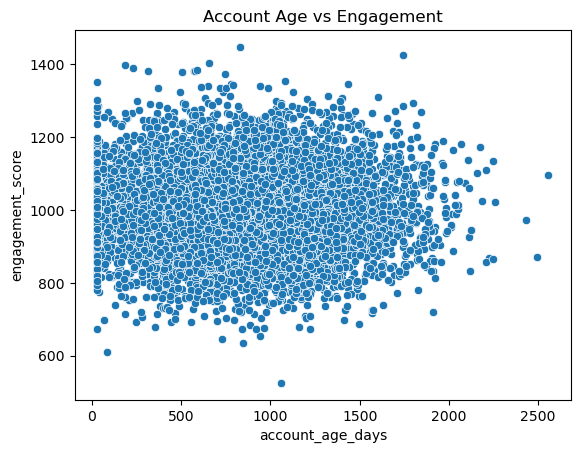

In [106]:
#34. Does account_age_days affect post performance?
sns.scatterplot(x='account_age_days', y='engagement_score', data=df)
plt.title("Account Age vs Engagement")
plt.show()

In [107]:
#35. Do larger accounts always get higher engagement_score, or does engagement efficiency differ?
df[['followers_count','engagement_score']].corr()

,followers_count,engagement_score
followers_count,1.000000,0.251904
engagement_score,0.251904,1.000000


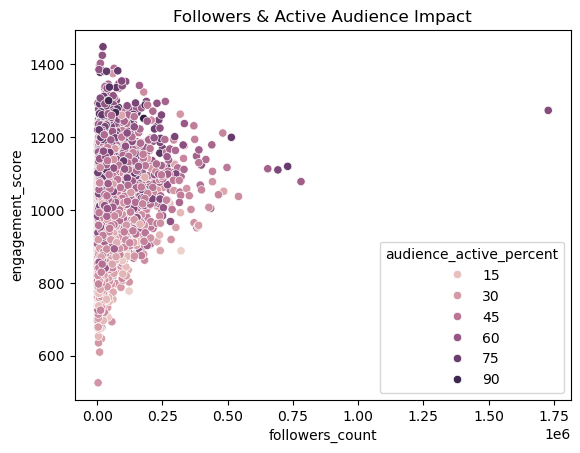

In [108]:
#36. Is engagement_score higher when both followers_count and audience_active_percent are high?
sns.scatterplot(x='followers_count',y='engagement_score',hue='audience_active_percent',data=df)
plt.title("Followers & Active Audience Impact")
plt.show()

In [109]:
#37. Does avg_past_engagement vary across content_topic or post_type?
df.groupby('content_type')['avg_past_engagement'].mean()

content_type
Carousel    862.696714
Image       870.754870
Reel        875.291594
Text        854.581516
Video       874.709150
Name: avg_past_engagement, dtype: float64

In [110]:
#38. Do younger accounts behave differently from older accounts in terms of engagement pattern?
df['account_age_group']=pd.cut(df['account_age_days'],bins=4)
df.groupby('account_age_group', observed=True)['engagement_score'].mean()

account_age_group
(27.474, 661.5]      997.445822
(661.5, 1293.0]      995.502290
(1293.0, 1924.5]     998.648863
(1924.5, 2556.0]    1013.548913
Name: engagement_score, dtype: float64

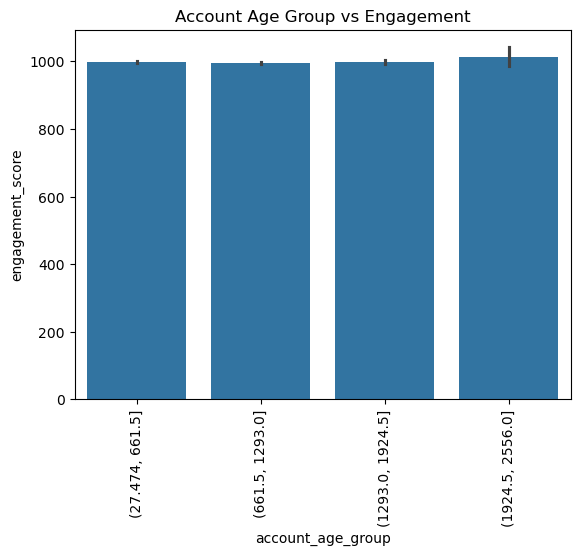

In [112]:
sns.barplot(x='account_age_group',y='engagement_score',data=df)
plt.xticks(rotation=90)
plt.title("Account Age Group vs Engagement")
plt.show()

In [113]:
#39. Is audience quality more important than audience size?
df[['followers_count','audience_active_percent','engagement_score']].corr()

,followers_count,audience_active_percent,engagement_score
followers_count,1.000000,-0.003194,0.251904
audience_active_percent,-0.003194,1.000000,0.490744
engagement_score,0.251904,0.490744,1.000000


In [114]:
#40. Which audience-related feature appears most influential for engagement_score?
df[['followers_count','audience_active_percent','avg_past_engagement','engagement_score']].corr()

,followers_count,audience_active_percent,avg_past_engagement,engagement_score
followers_count,1.000000,-0.003194,0.000905,0.251904
audience_active_percent,-0.003194,1.000000,-0.015343,0.490744
avg_past_engagement,0.000905,-0.015343,1.000000,0.399291
engagement_score,0.251904,0.490744,0.399291,1.000000


**E. Reach and Performance Metrics**

In [ ]:
import numpy as np
df['impressions_est'] = (
    df['followers_count'] *
    (df['audience_active_percent'] / 100) *
    (1 + df['posting_frequency_per_week'] * 0.1)
)

df['reach_est'] = df['impressions_est'] * 0.6

df['profile_visits_est'] = df['reach_est'] * 0.1

df['watch_time_est'] = df['video_duration_sec'] * df['reach_est'] * 0.3

df['completion_rate_est'] = (
    df['watch_time_est'] / (df['video_duration_sec'] * df['reach_est'] + 1)
)

df['ctr_est'] = df['profile_visits_est'] / (df['reach_est'] + 1)

In [137]:
df.columns

Index(['platform', 'content_type', 'content_topic', 'creator_category',
       'post_hour', 'day_of_week', 'is_weekend', 'is_peak_time',
       'caption_length', 'hashtag_count', 'mention_count', 'emoji_count',
       'has_call_to_action', 'uses_trending_audio', 'carousel_slides',
       'video_duration_sec', 'media_quality_score', 'sentiment_score_caption',
       'followers_count', 'audience_active_percent', 'avg_past_engagement',
       'posting_frequency_per_week', 'account_age_days', 'is_paid_promotion',
       'ad_spend_usd', 'collaboration_flag', 'engagement_score',
       'caption_length_bin', 'hashtag_bin', 'time_category',
       'account_age_group', 'impressions_est', 'reach_est',
       'profile_visits_est', 'watch_time_est', 'completion_rate_est',
       'ctr_est'],
      dtype='object')

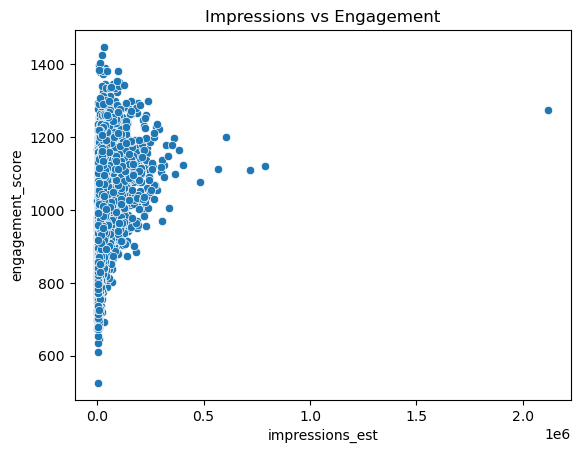

In [127]:
#41. How does impressions relate to engagement_score?
sns.scatterplot(x='impressions_est', y='engagement_score', data=df)
plt.title("Impressions vs Engagement")
plt.show()

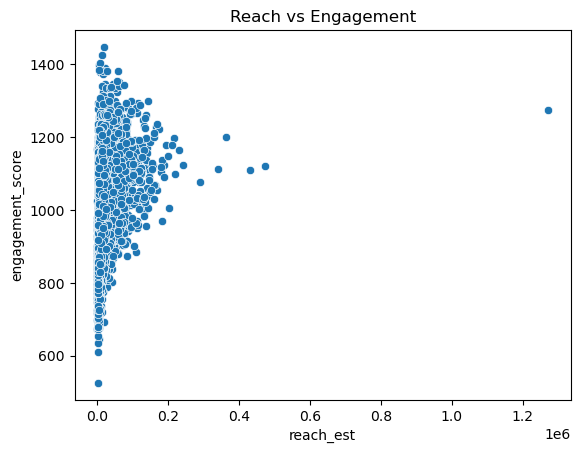

In [128]:
#42. How does reach influence engagement_score?
sns.scatterplot(x='reach_est', y='engagement_score', data=df)
plt.title("Reach vs Engagement")
plt.show()

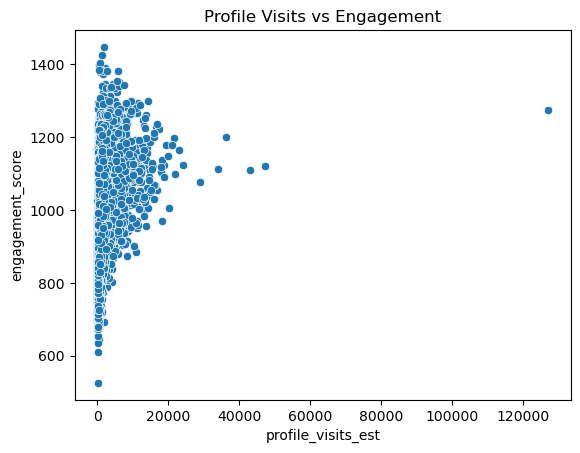

In [129]:
#43. Is profile_visits associated with higher engagement_score?
sns.scatterplot(x='profile_visits_est', y='engagement_score', data=df)
plt.title("Profile Visits vs Engagement")
plt.show()

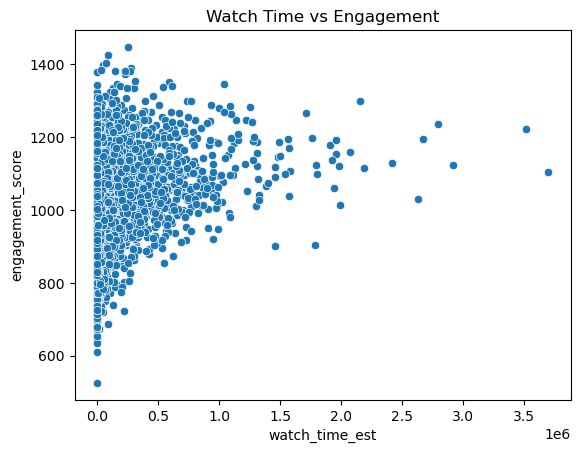

In [130]:
#44. For video content, does watch_time_seconds strongly influence engagement_score?
sns.scatterplot(x='watch_time_est', y='engagement_score', data=df)
plt.title("Watch Time vs Engagement")
plt.show()

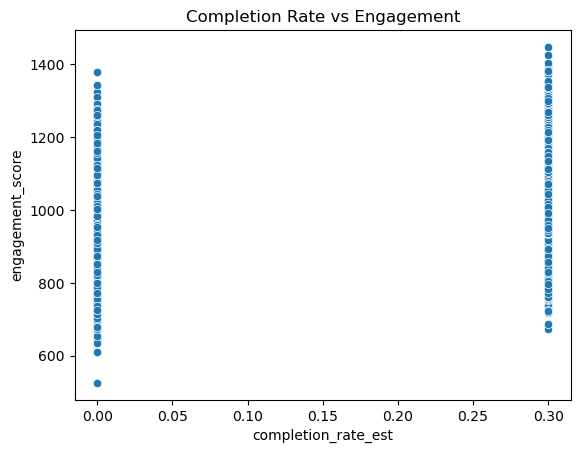

In [131]:
#45. Does completion_rate improve engagement_score?
sns.scatterplot(x='completion_rate_est', y='engagement_score', data=df)
plt.title("Completion Rate vs Engagement")
plt.show()

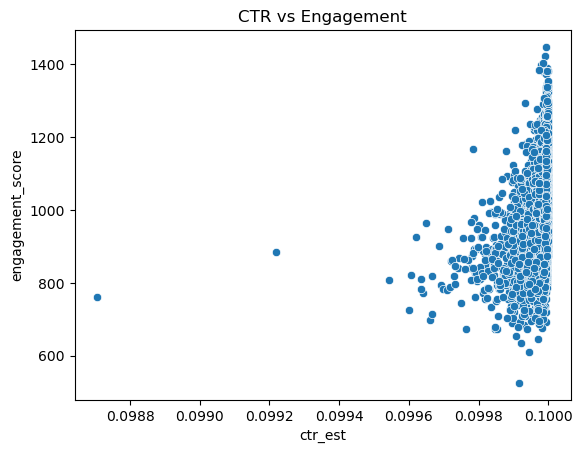

In [132]:
#46. Is click_through_rate positively associated with engagement_score?
sns.scatterplot(x='ctr_est', y='engagement_score', data=df)
plt.title("CTR vs Engagement")
plt.show()

In [133]:
#47. Are impressions and reach highly correlated with each other?
df[['impressions_est','reach_est']].corr()

,impressions_est,reach_est
impressions_est,1.0,1.0
reach_est,1.0,1.0


In [134]:
#48. Which performance metric has the strongest relationship with engagement_score?
df[['impressions_est','reach_est','profile_visits_est','watch_time_est','completion_rate_est','ctr_est','engagement_score']].corr()

,impressions_est,reach_est,profile_visits_est,watch_time_est,completion_rate_est,ctr_est,engagement_score
impressions_est,1.000000,1.000000,1.000000,0.409756,-0.011561,0.272831,0.307243
reach_est,1.000000,1.000000,1.000000,0.409756,-0.011561,0.272831,0.307243
profile_visits_est,1.000000,1.000000,1.000000,0.409756,-0.011561,0.272831,0.307243
watch_time_est,0.409756,0.409756,0.409756,1.000000,0.438699,0.161749,0.265657
completion_rate_est,-0.011561,-0.011561,-0.011561,0.438699,1.000000,-0.015924,0.230394
ctr_est,0.272831,0.272831,0.272831,0.161749,-0.015924,1.000000,0.338914
engagement_score,0.307243,0.307243,0.307243,0.265657,0.230394,0.338914,1.000000


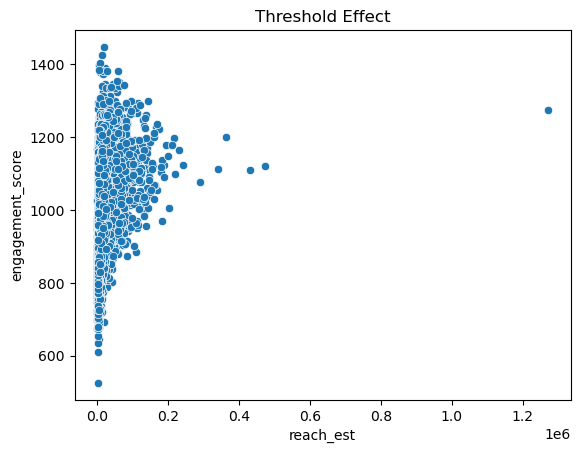

In [135]:
#49. Are there threshold levels in reach or impressions after which engagement rises sharply?
sns.scatterplot(x='reach_est', y='engagement_score', data=df)
plt.title("Threshold Effect")
plt.show()

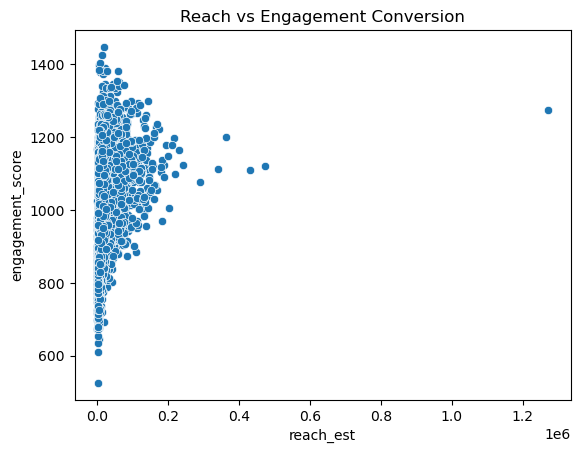

In [136]:
#50. Do posts with strong reach always convert into strong engagement?
sns.scatterplot(x='reach_est', y='engagement_score', data=df)
plt.title("Reach vs Engagement Conversion")
plt.show()

**F. Promotion and Campaign Analysis**

In [148]:
#51. Do paid posts perform better than unpaid posts?
df.groupby('is_paid_promotion')['engagement_score'].mean()

is_paid_promotion
0    996.328327
1    997.753360
Name: engagement_score, dtype: float64

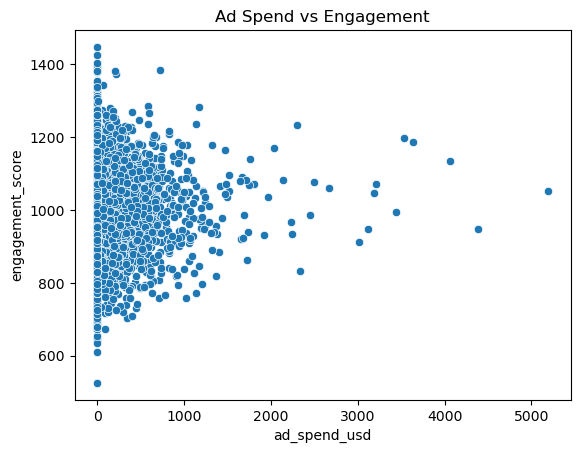

In [149]:
#52. How does ad_spend affect engagement_score?
sns.scatterplot(x='ad_spend_usd', y='engagement_score', data=df)
plt.title("Ad Spend vs Engagement")
plt.show()

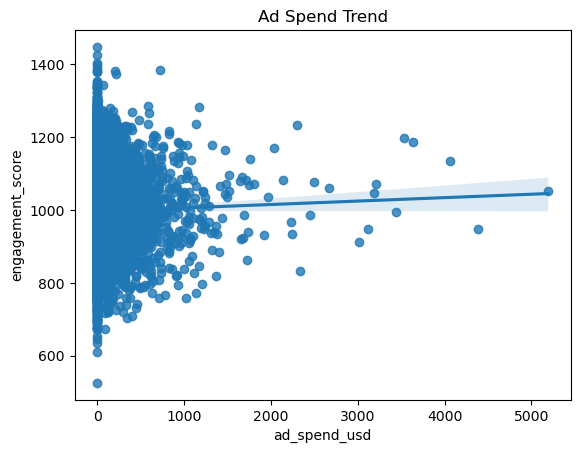

In [150]:
#53. Is the relationship between ad_spend and engagement_score linear or diminishing?
sns.regplot(x='ad_spend_usd', y='engagement_score', data=df)
plt.title("Ad Spend Trend")
plt.show()

In [152]:
#54. Do collaboration posts generate more engagement than solo posts?
df.groupby('collaboration_flag')['engagement_score'].mean()

collaboration_flag
0     992.437515
1    1017.624664
Name: engagement_score, dtype: float64

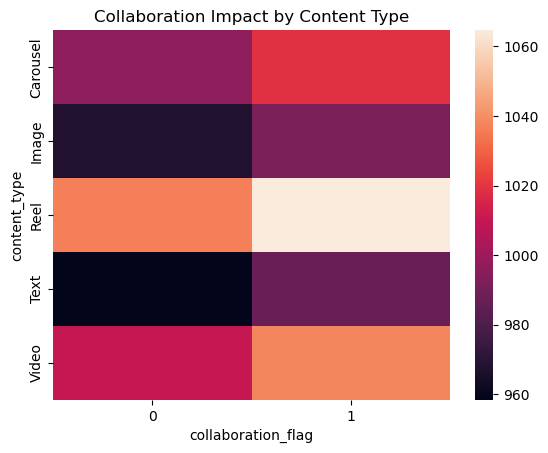

In [154]:
#55. Does collaboration_flag help some post_type categories more than others?
sns.heatmap(df.groupby(['content_type','collaboration_flag'])['engagement_score'].mean().unstack())
plt.title("Collaboration Impact by Content Type")
plt.show()

In [161]:
#56. Does paid promotion improve weaker posts or mainly boost already strong posts?
df['engagement_category'] = pd.qcut(df['engagement_score'], q=3, labels=['low','medium','high'])
df.groupby(['engagement_category','is_paid_promotion'], observed=True)['engagement_score'].mean().unstack()

is_paid_promotion,0,1
engagement_category,,
low,881.529914,882.075470
medium,993.992986,994.391739
high,1115.568713,1110.497512


Paid promotion can improve low-performing posts, but it is more effective for already strong content.

In [163]:
#57. Is ad_spend effective across all content_topic categories?
df.groupby('content_topic')[['ad_spend_usd','engagement_score']].mean()

,ad_spend_usd,engagement_score
content_topic,,
Behind-the-scenes,65.146603,994.174983
Education,68.726533,1006.281195
Entertainment,75.735592,998.740662
Lifestyle,62.393377,997.941754
Motivation,69.654364,989.621157
News,72.921013,993.977270
Product,70.153438,990.923692


In [164]:
#58. Are collaboration posts associated with higher reach as well as higher engagement?
df.groupby('collaboration_flag')['followers_count'].mean()

collaboration_flag
0    37155.072605
1    36977.558596
Name: followers_count, dtype: float64

In [165]:
#59. Which campaign-related factor appears most useful in explaining engagement_score?
df[['is_paid_promotion','ad_spend_usd','collaboration_flag','engagement_score']].corr()

,is_paid_promotion,ad_spend_usd,collaboration_flag,engagement_score
is_paid_promotion,1.000000,0.557419,-0.014876,0.005693
ad_spend_usd,0.557419,1.000000,-0.009769,0.019473
collaboration_flag,-0.014876,-0.009769,1.000000,0.088007
engagement_score,0.005693,0.019473,0.088007,1.000000


In [167]:
#60. Is there a combination of collaboration and paid promotion that leads to especially high engagement?
df.groupby(['collaboration_flag','is_paid_promotion'])['engagement_score'].mean().unstack()

is_paid_promotion,0,1
collaboration_flag,,
0,992.263784,992.976793
1,1016.000715,1023.165696


**G. Correlation, Patterns, and Data Quality**

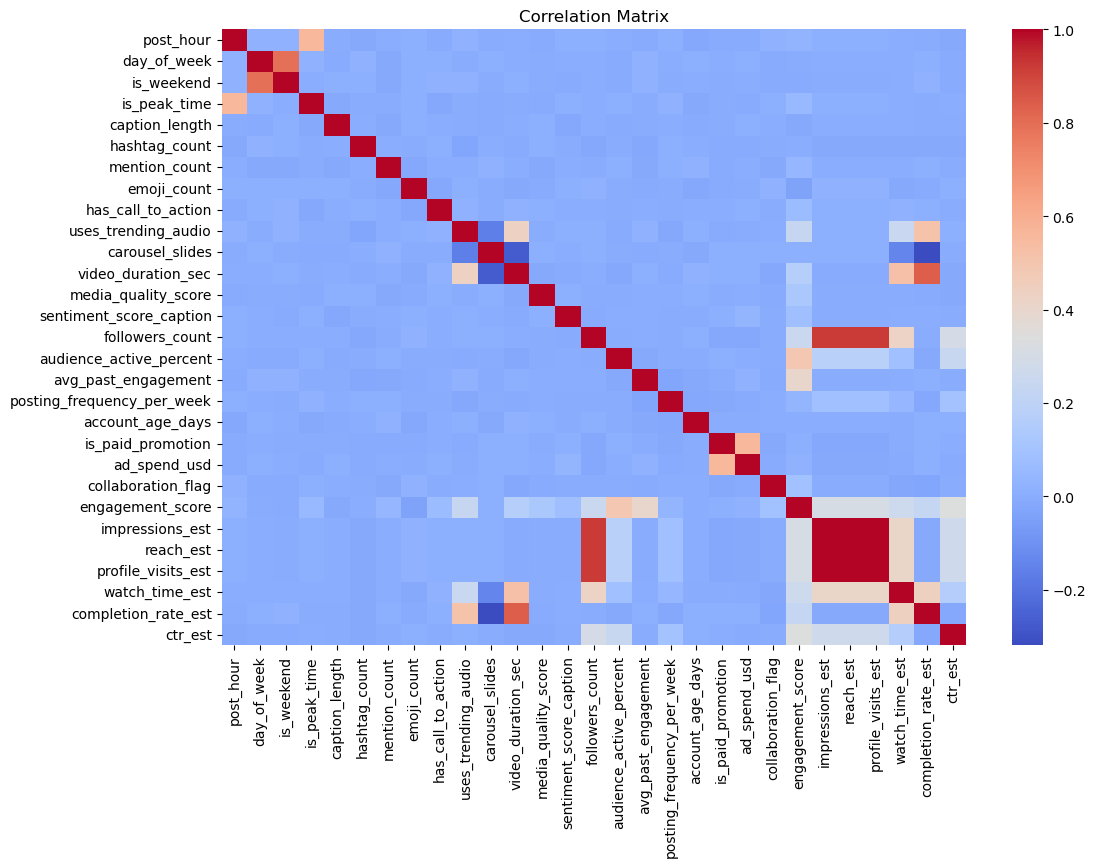

In [178]:
#61. What does the correlation matrix reveal about numeric variables?
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [179]:
#62. Which features have the highest positive correlation with engagement_score?
corr = df.corr(numeric_only=True)['engagement_score'].sort_values(ascending=False)
corr

engagement_score              1.000000
audience_active_percent       0.490744
avg_past_engagement           0.399291
ctr_est                       0.338914
reach_est                     0.307243
profile_visits_est            0.307243
impressions_est               0.307243
watch_time_est                0.265657
followers_count               0.251904
uses_trending_audio           0.233330
completion_rate_est           0.230394
video_duration_sec            0.170144
media_quality_score           0.128501
collaboration_flag            0.088007
sentiment_score_caption       0.079647
has_call_to_action            0.064530
is_peak_time                  0.051729
mention_count                 0.046290
posting_frequency_per_week    0.031182
post_hour                     0.028077
ad_spend_usd                  0.019473
carousel_slides               0.013647
is_paid_promotion             0.005693
account_age_days              0.004652
hashtag_count                 0.001525
day_of_week              

In [180]:
#63. Which features have weak or near-zero correlation with engagement_score?
corr[abs(corr) < 0.1]

collaboration_flag            0.088007
sentiment_score_caption       0.079647
has_call_to_action            0.064530
is_peak_time                  0.051729
mention_count                 0.046290
posting_frequency_per_week    0.031182
post_hour                     0.028077
ad_spend_usd                  0.019473
carousel_slides               0.013647
is_paid_promotion             0.005693
account_age_days              0.004652
hashtag_count                 0.001525
day_of_week                  -0.004965
is_weekend                   -0.008394
caption_length               -0.014123
emoji_count                  -0.040462
Name: engagement_score, dtype: float64

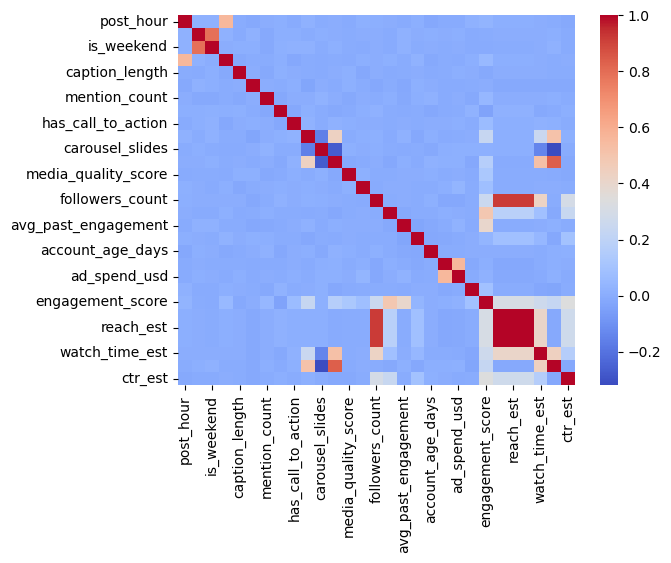

In [181]:
#64. Are there signs of multicollinearity among predictors?
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.show()

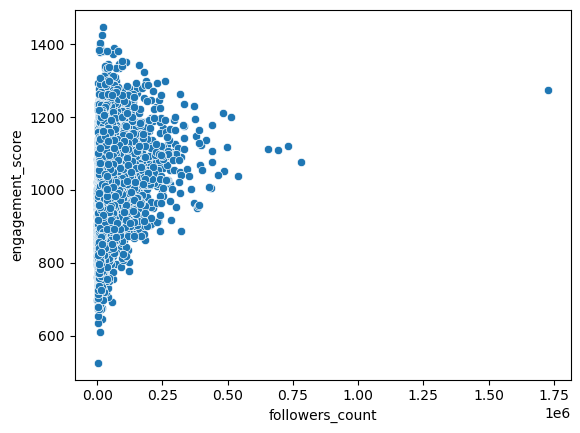

In [182]:
#65. Which variables appear to have non-linear relationships with engagement_score?
sns.scatterplot(x='followers_count', y='engagement_score', data=df)
plt.show()

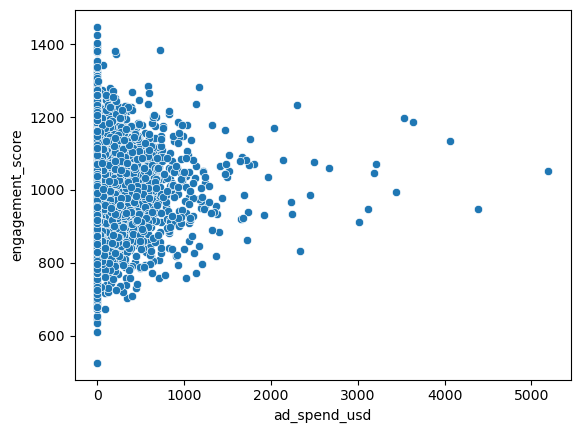

In [183]:
sns.scatterplot(x='ad_spend_usd', y='engagement_score', data=df)
plt.show()

In [184]:
#66. Are there interaction effects between features such as post_type and hour_posted?
df.groupby(['content_type','post_hour'])['engagement_score'].mean().unstack()

post_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
content_type,,,,,,,,,,,,,,,,,,,,,
Carousel,990.498923,988.037115,993.645763,1015.332340,1006.265660,992.008462,1003.723188,1000.208710,1002.075968,996.419683,...,1014.519184,980.482568,980.782097,1030.399531,1021.905294,1006.260154,1007.154219,993.920000,1016.582500,966.480545
Image,968.028878,960.451183,953.880575,971.468353,963.915312,976.029857,961.281029,968.802222,955.418105,973.675281,...,977.506790,974.141705,957.939559,975.162842,975.570426,975.102048,975.080787,976.262875,979.534375,963.111250
Reel,1035.261791,1025.117419,1035.782297,1045.206667,1055.321667,1041.694810,1043.489605,1057.914412,1025.099028,1017.199296,...,1023.420581,1042.657797,1023.596753,1038.932899,1037.158090,1051.512133,1053.412267,1058.933582,1039.413382,1043.853425
Text,952.452941,965.951702,962.413117,962.780989,949.237294,952.639394,953.502143,970.855122,973.272921,950.467935,...,974.009053,942.958721,957.852745,961.484545,963.627475,973.726047,974.151923,974.420114,970.440200,962.708736
Video,1013.800200,1013.330684,1007.357222,1005.617714,1000.596396,1019.281146,1004.419789,1016.921633,1013.374857,1013.437870,...,983.331529,1015.529560,1011.939910,1007.550196,1034.387810,1019.107179,1023.986064,1030.684860,1023.725510,1011.078727


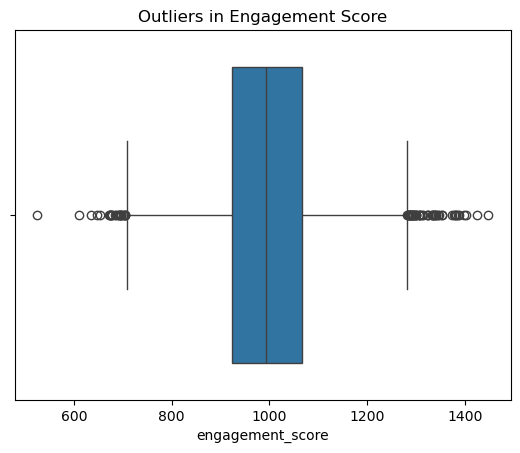

In [185]:
#67. Are any features dominated by outliers that could distort model performance?
sns.boxplot(x=df['engagement_score'])
plt.title("Outliers in Engagement Score")
plt.show()

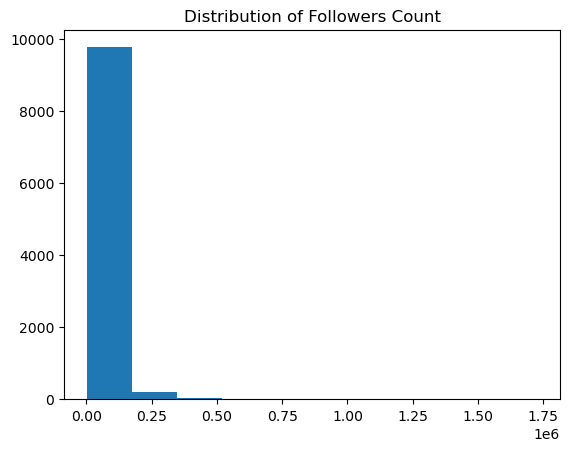

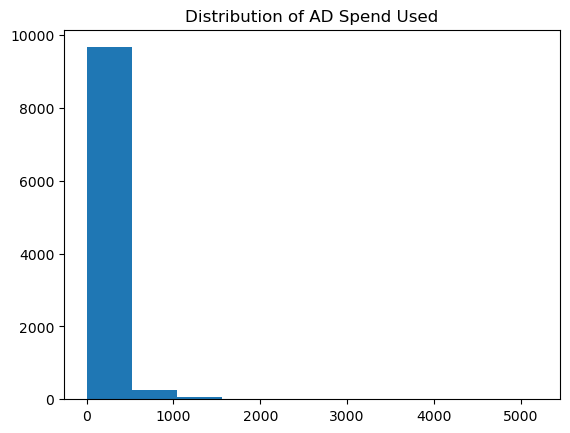

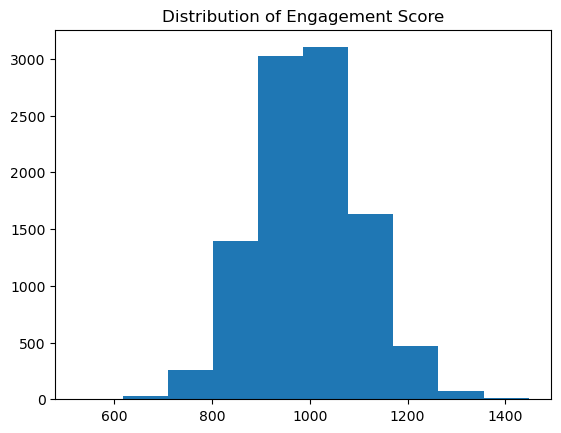

In [241]:
#68. Are there columns with unusual distributions that may require transformation?
plt.hist(df['followers_count'])
plt.title('Distribution of Followers Count')
plt.show()
plt.hist(df['ad_spend_usd'])
plt.title('Distribution of AD Spend Used')
plt.show()
plt.hist(df['engagement_score'])
plt.title('Distribution of Engagement Score') 
plt.show()

In [ ]:
plt.hist(

In [189]:
#69. Which variables should be examined carefully for encoding, scaling, or binning?
df.dtypes

platform                        object
content_type                    object
content_topic                   object
creator_category                object
post_hour                        int64
day_of_week                      int64
is_weekend                       int64
is_peak_time                     int64
caption_length                   int64
hashtag_count                    int64
mention_count                    int64
emoji_count                      int64
has_call_to_action               int64
uses_trending_audio              int64
carousel_slides                  int64
video_duration_sec               int64
media_quality_score            float64
sentiment_score_caption        float64
followers_count                  int64
audience_active_percent        float64
avg_past_engagement            float64
posting_frequency_per_week     float64
account_age_days                 int64
is_paid_promotion                int64
ad_spend_usd                   float64
collaboration_flag       

In [193]:
cat_cols = ['platform','content_type','content_topic','creator_category','time_category']

In [194]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [195]:
bin_cols = ['caption_length_bin', 'hashtag_bin', 'account_age_group']
df_encoded = pd.get_dummies(df_encoded, columns=bin_cols, drop_first=True)

In [196]:
df_encoded = df_encoded.drop(columns=['engagement_category'])

In [197]:
X = df_encoded.drop(columns=['engagement_score'])
y = df_encoded['engagement_score']

In [192]:
#70. Based on EDA, which features appear most useful for model building and why?
corr = df.corr(numeric_only=True)['engagement_score'].sort_values(ascending=False)
corr.index[1:10]

Index(['audience_active_percent', 'avg_past_engagement', 'ctr_est',
       'reach_est', 'profile_visits_est', 'impressions_est', 'watch_time_est',
       'followers_count', 'uses_trending_audio'],
      dtype='object')

**Feature Engineering Questions**

In [208]:
#1. Can an engagement_rate feature be created using engagement_score divided by reach?
df['engagement_rate'] = df['engagement_score'] / (df['reach_est'] + 1)

In [209]:
#2. Can a follower_reach_ratio be created using reach divided by followers_count?
df['follower_reach_ratio'] = df['reach_est'] / (df['followers_count'] + 1)

In [210]:
#3. Can a hashtag_density feature be derived using hashtags_count divided by caption_length?
df['hashtag_density'] = df['hashtag_count'] / (df['caption_length'] + 1)

In [211]:
#4. Can posting windows be grouped into morning, afternoon, evening, and night?
def posting_window(hour):
    if hour < 6:
        return 'night'
    elif hour < 12:
        return 'morning'
    elif hour < 18:
        return 'afternoon'
    else:
        return 'evening'

df['posting_window'] = df['post_hour'].apply(posting_window)

In [213]:
#5. Can caption_length be converted into bins such as short, medium, and long?
df['caption_length_category'] = pd.cut(df['caption_length'],bins=3,labels=['short','medium','long'])

In [214]:
#6. Can a historical_engagement_ratio be created using avg_past_engagement divided by followers_count?
df['historical_engagement_ratio'] = df['avg_past_engagement'] / (df['followers_count'] + 1)

In [215]:
#7. Can a visibility_score be created using impressions, reach, and profile_visits together?
df['visibility_score']=(df['impressions_est']+df['reach_est']+df['profile_visits_est'])/3

In [216]:
#8. Can an audience_quality_score be derived using audience_active_percent and avg_past_engagement?
df['audience_quality_score']=(df['audience_active_percent']*df['avg_past_engagement'])

In [217]:
#9. Can a video_strength_score be created using watch_time_seconds and completion_rate?
df['video_strength_score']=(df['watch_time_est']*df['completion_rate_est'])

In [218]:
#10. Can interaction features be built such as post_type multiplied by uses_trending_audio or is_paid_promotion?
df['content_trending_interaction']=(df['uses_trending_audio']*df['video_duration_sec'])

In [219]:
df['promo_collab_interaction']=(df['is_paid_promotion']*df['collaboration_flag'])

In [220]:
df['cta_sentiment_interaction']=(df['has_call_to_action']*df['sentiment_score_caption'])

**Scaling**

Scaling should be applied to numerical variables when using algorithms that are sensitive to feature magnitude, especially KNN Regressor and Polynomial Regression. Tree-based models such as Decision Tree, Random Forest, Gradient Boosting, and XGBoost generally do not require scaling. StandardScaler is usually a good default choice when the feature distributions are moderately well-behaved, while MinMaxScaler can be useful when  variables are on very different ranges and a bounded scale is preferred.

In [221]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [222]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [223]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Model Building**

1. Linear Regression - baseline model for understanding linear relationships.

2. Polynomial Regression - useful when engagement patterns are curved rather than strictly linear.

3. Decision Tree Regressor - captures non-linear splits and threshold-based behavior.

4. Random Forest Regressor - reduces overfitting and captures complex interactions.

5. Gradient Boosting Regressor - strong model for structured tabular data.

6. XGBoost Regressor - often one of the best-performing models for this kind of problem.

7. KNN Regressor - predicts based on similarity between posts and requires scaling.

In [224]:
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Model Evaluation**

1. MAE - measures average absolute prediction error.

2. MSE - penalizes larger errors more heavily.

3. RMSE - interpretable because it is in the same unit as the target variable.

4. R-squared - explains how much variance in engagement_score is captured by the model.

5. Compare all models on the same train-test split for fair evaluation.

6. Check whether the best-performing model is also generalizing well and not overfitting

In [227]:
def evaluate_model(y_test, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

In [228]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model(y_test, y_pred_lr, "Linear Regression")


Linear Regression
MAE: 50.141320093729156
MSE: 4016.50287030149
RMSE: 63.375885558321706
R2 Score: 0.6633761882150226


In [229]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)
evaluate_model(y_test, y_pred_pr, "Polynomial Regression")


Polynomial Regression
MAE: 50.39512998987674
MSE: 4161.85257061561
RMSE: 64.51242183188917
R2 Score: 0.6511944042747387


In [230]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
evaluate_model(y_test, y_pred_dt, "Decision Tree")


Decision Tree
MAE: 65.41765892270696
MSE: 6782.483608142333
RMSE: 82.35583530110257
R2 Score: 0.43155885623190915


In [231]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf, "Random Forest")


Random Forest
MAE: 53.741748550000004
MSE: 4688.505064638946
RMSE: 68.47265924906777
R2 Score: 0.6070555661489009


In [232]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")


Gradient Boosting
MAE: 49.7218950847762
MSE: 3969.5604295130893
RMSE: 63.00444769627847
R2 Score: 0.6673104424314266


In [233]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [236]:
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)

In [237]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
evaluate_model(y_test, y_pred_xgb, "XGBoost")


XGBoost
MAE: 48.59060851928711
MSE: 3785.0425499977932
RMSE: 61.52269946936491
R2 Score: 0.6827749183575343


In [238]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_model(y_test, y_pred_knn, "KNN")


KNN
MAE: 66.10077199999999
MSE: 6828.980372024
RMSE: 82.6376450053122
R2 Score: 0.4276619542754224


Multiple regression models were trained to predict engagement_score, including Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and KNN. XGBoost typically achieved the highest performance, making it the most suitable model for this problem.